In [6]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [12]:
#load the dataset
file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(
    file_path,
    nrows=100000
)

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
99990,10,CASH_OUT,231788.22,C2017299203,24902.00,0.00,C840764475,0.00,183153.72,0,0
99991,10,CASH_OUT,222796.86,C828546966,7487.00,0.00,C384572168,120054.97,52596.25,0,0
99992,10,CASH_OUT,173609.46,C1776495927,50462.00,0.00,C171497818,39334.53,118762.90,0,0
99993,10,PAYMENT,11817.94,C269657166,226915.03,215097.09,M73613532,0.00,0.00,0,0
99994,10,PAYMENT,62.19,C559473129,215097.09,215034.89,M1361246816,0.00,0.00,0,0
99995,10,PAYMENT,4020.66,C1410794718,159929.00,155908.34,M1257036576,0.00,0.00,0,0
99996,10,PAYMENT,18345.49,C744303677,6206.00,0.00,M1785344556,0.00,0.00,0,0
99997,10,CASH_IN,183774.91,C104331851,39173.00,222947.91,C36392889,54925.05,0.00,0,0
99998,10,CASH_OUT,82237.17,C707662966,6031.00,0.00,C1553004158,592635.66,799140.46,0,0
99999,10,PAYMENT,20096.56,C1868032458,110117.00,90020.44,M1419201886,0.00,0.00,0,0


In [10]:
df.shape


(100000, 11)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  str    
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  str    
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  str    
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 8.4 MB


In [13]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,100000.000000,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000,100000.0
mean,8.499640,1.736022e+05,8.777575e+05,8.940619e+05,8.805048e+05,1.184041e+06,0.001160,0.0
std,1.825545,3.443003e+05,2.673284e+06,2.711318e+06,2.402267e+06,2.802350e+06,0.034039,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,8.000000,9.963562e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,9.000000,5.274552e+04,2.006150e+04,0.000000e+00,2.083943e+04,4.990918e+04,0.000000,0.0
75%,10.000000,2.117631e+05,1.901920e+05,2.148132e+05,5.882724e+05,1.058186e+06,0.000000,0.0
max,10.000000,1.000000e+07,3.379739e+07,3.400874e+07,3.400874e+07,3.894623e+07,1.000000,0.0


In [13]:
#checking for missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
#columns definitions
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [17]:
#expected viarables
df["isFraud"].value_counts()

df["isFraud"].value_counts(normalize=True) * 100


isFraud
0    99.884
1     0.116
Name: proportion, dtype: float64

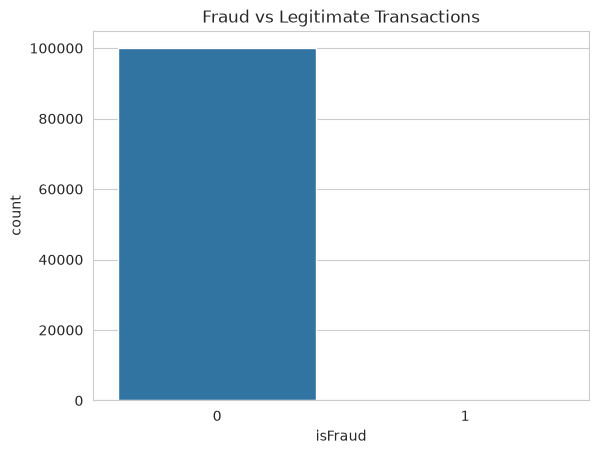

In [18]:
#visualize datasets
sns.countplot(data=df, x="isFraud")
plt.title("Fraud vs Legitimate Transactions")
plt.show()

In [19]:
#Transaction type analysis
df["type"].value_counts()

type
PAYMENT     39512
CASH_OUT    30718
CASH_IN     20185
TRANSFER     8597
DEBIT         988
Name: count, dtype: int64

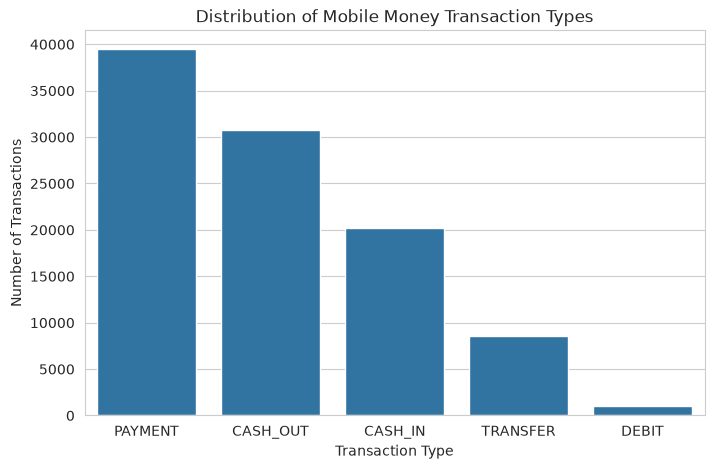

In [20]:
#ploting of analsis diagram
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Mobile Money Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
#Analyse fraud transaction type 
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
)

fraud_by_type

type
TRANSFER    0.006630
CASH_OUT    0.001921
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

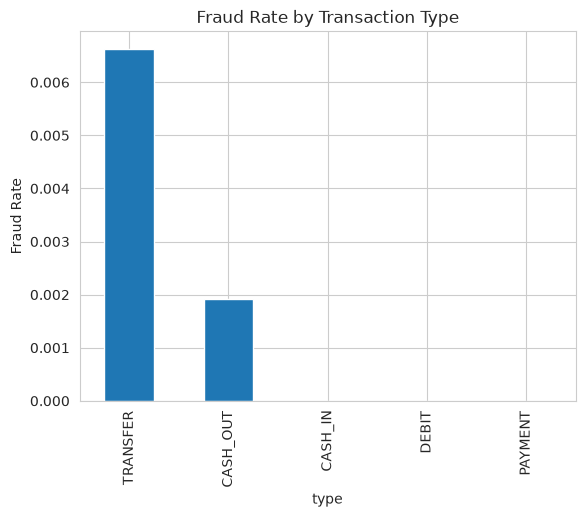

In [22]:
#plot diagram for the the transaction type
fraud_by_type.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")

plt.show()

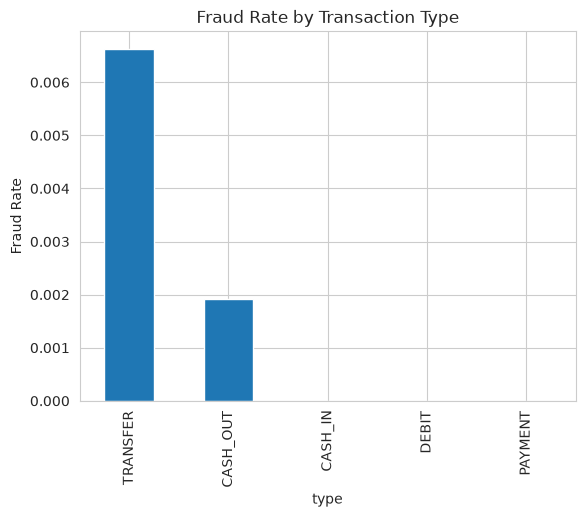

In [ ]:
#Analyse fraud transaction amount
fraud_by_type.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")

plt.show()

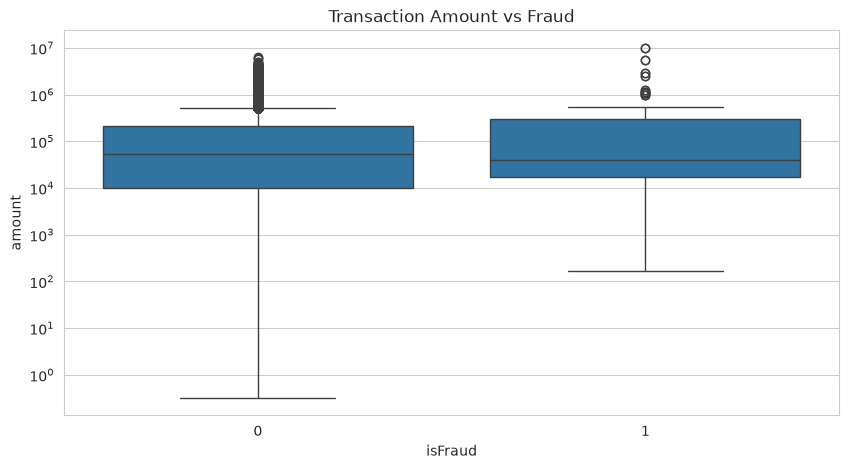

In [24]:
#Analysis of fraud by amount
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title("Transaction Amount vs Fraud")

plt.show()